# Визуализация результатов SSL-предоубечения на 7 каналах (masked reconstruction) полного

## Train vs Val loss

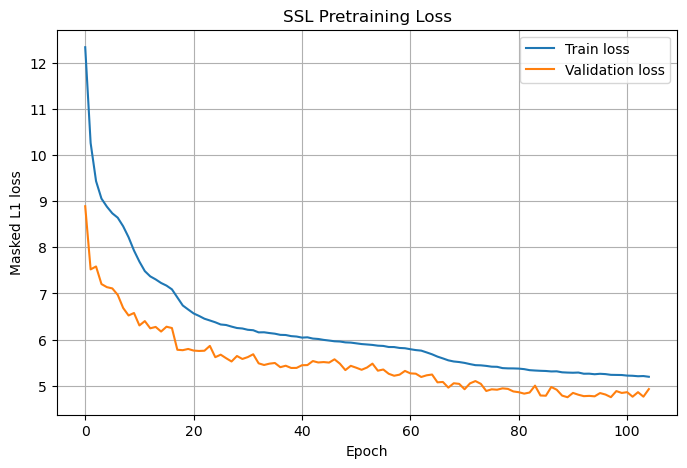

In [2]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

Loss_hystory_path = Path(r'C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\SSL_masked_reconstruction_ОСНОВНОЙ_ЭКСПЕРИМЕНТ\results\ssl_checkpoints\loss_history.json')

with open(Loss_hystory_path) as f:
    hist = json.load(f)

train_loss = hist["train_loss"]
val_loss = hist["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(train_loss, label="Train loss")
plt.plot(val_loss, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Masked L1 loss")
plt.title("SSL Pretraining Loss")
plt.legend()
plt.grid(True)

plt.show()

## Train vs Val loss с Лучшей эпохой

Ключи в файле: dict_keys(['train_loss', 'val_loss'])
Лучшая эпоха: 17
Лучшее значение val_loss: 3.011442


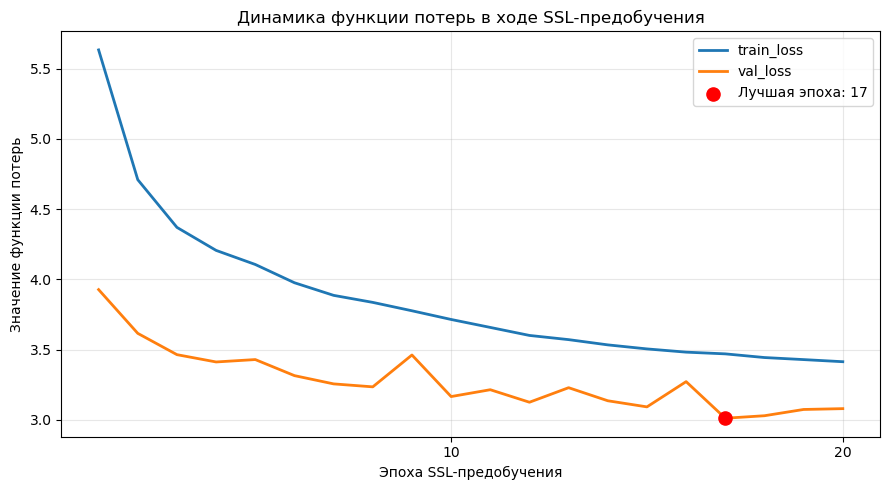

In [2]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Укажи путь к файлу
path = Path(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\ssl_ch7\logs\loss_history.json")

# === 2. Загрузка истории ===
with open(path, "r", encoding="utf-8") as f:
    history = json.load(f)

print("Ключи в файле:", history.keys())

# === 3. Эпохи ===
if "epoch" in history:
    epochs = np.array(history["epoch"])
else:
    n = len(history["val_loss"])
    epochs = np.arange(1, n + 1)

train_loss = np.array(history["train_loss"]) if "train_loss" in history else None
val_loss = np.array(history["val_loss"])

# === 4. Лучшая эпоха ===
best_idx = np.argmin(val_loss)
best_epoch = epochs[best_idx]
best_val_loss = val_loss[best_idx]

print(f"Лучшая эпоха: {best_epoch}")
print(f"Лучшее значение val_loss: {best_val_loss:.6f}")

# === 5. Подписи по оси X: каждая 10-я эпоха и 105 ===
xticks = [e for e in epochs if e % 10 == 0]
if 105 in epochs and 105 not in xticks:
    xticks.append(105)
xticks = sorted(xticks)

# === 6. График ===
plt.figure(figsize=(9, 5))

if train_loss is not None:
    plt.plot(epochs, train_loss, linewidth=2, label="train_loss")

plt.plot(epochs, val_loss, linewidth=2, label="val_loss")

# Лучшая эпоха поверх графика
plt.scatter(
    best_epoch,
    best_val_loss,
    color="red",
    s=90,
    zorder=10,
    label=f"Лучшая эпоха: {best_epoch}"
)

plt.xlabel("Эпоха SSL-предобучения")
plt.ylabel("Значение функции потерь")
plt.title("Динамика функции потерь в ходе SSL-предобучения")
plt.xticks(xticks)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Сохранение
save_dir = Path(r"C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\ssl_ch7\figures")
save_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(save_dir / "ssl_loss_curve_withBest.png", dpi=300, bbox_inches="tight")
plt.savefig(save_dir / "ssl_loss_curve_withBest.pdf", bbox_inches="tight")

plt.show()
